# Hybrid degradation analysis (PVDAQ system 4)

This notebook applies the two-piece hybrid degradation analysis
(`rdtools.degradation_hybrid`) to PVDAQ system 4 -- the same dataset used
in [`TrendAnalysis_example.ipynb`](TrendAnalysis_example.ipynb).

The hybrid method splits the normalized-energy time series at the
1-year mark and fits a user-selected regression on the year-1 window
plus the year-on-year (YoY) method on the years-2+ window:

- **Year 1** — a rate in %/year of the year-0 system capacity from
  whichever year-1 estimator you pick.
- **Years 2+** — a steady-state rate in %/year of the start-of-year-2
  capacity (when `recenter_year2=True`) from
  [`degradation_year_on_year`](../api.html#rdtools.degradation_year_on_year).

This decomposition is useful when the first year of operation degrades
qualitatively differently from steady state (light-induced degradation,
light-soaking, initial stabilization). A single-rate fit over the whole
record averages the two regimes and hides the nonlinearity.

The notebook walks through two increasingly sophisticated
configurations for the year-1 piece:

- **§3–4: simple hybrid.** Use
  [`degradation_theil_sen`](../api.html#rdtools.degradation_theil_sen)
  on the raw year-1 window -- a robust median-of-pairwise-slopes fit
  that treats the seasonal wiggle as residual noise. Fast and easy;
  what "hybrid" meant before the seasonal machinery existed.
- **§5: seasonal hybrid.** Use
  [`degradation_fourier`](../api.html#rdtools.degradation_fourier),
  which first learns a seasonal Fourier shape from the multi-year
  record, subtracts it from year 1, and only then fits the year-1
  slope. More data-hungry but less biased when the seasonal amplitude
  is comparable to the year-1 trend.

For full data preparation and the broader `TrendAnalysis` workflow, see
[`TrendAnalysis_example.ipynb`](TrendAnalysis_example.ipynb). This
notebook focuses on the hybrid-specific configuration and outputs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pvlib
import rdtools
%matplotlib inline


In [2]:
# Update the style of plots
import matplotlib
matplotlib.rcParams.update({'font.size': 12,
                            'figure.figsize': [4.5, 3],
                            'lines.markeredgewidth': 0,
                            'lines.markersize': 2})
# Register time series plotting in pandas > 1.0
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()


In [3]:
# Set the random seed for numpy so the bootstrap-based YoY confidence
# intervals are reproducible across runs.
np.random.seed(0)


## 1. Import and prepare data

Loads PVDAQ system 4 from the cached CSV and assembles the metadata dict
needed by `TrendAnalysis`. The data preparation here mirrors
`TrendAnalysis_example.ipynb`, minus the synthetic soiling multiplication
(we run the hybrid fit on the AC power directly so the result isn't
distorted by the synthetic signal).


In [4]:
# Import the example data
file_url = ('https://github.com/NatLabRockies/rdtools/releases/download/3.0.0/'
            'pvdaq_system_4_2010-2016_subset_soil_signal.csv')
cache_file = 'PVDAQ_system_4_2010-2016_subset_soilsignal.pickle'

try:
    df = pd.read_pickle(cache_file)
except FileNotFoundError:
    df = pd.read_csv(file_url, index_col=0, parse_dates=True)
    df.to_pickle(cache_file)


In [5]:
df = df.rename(columns={
    'ac_power': 'power_ac',
    'wind_speed': 'wind_speed',
    'ambient_temp': 'Tamb',
    'poa_irradiance': 'poa',
})

# Specify the Metadata
meta = {"latitude": 39.7406,
        "longitude": -105.1774,
        "timezone": 'Etc/GMT+7',
        "gamma_pdc": -0.0034,  # 1/K, modern silicon PV modules
        "azimuth": 180,
        "tilt": 40,
        "power_dc_rated": 1000.0,
        "temp_model_params": 'open_rack_glass_polymer'}

df.index = df.index.tz_localize(meta['timezone'])

# Some missing data, so infer the frequency from the first few points.
freq = pd.infer_freq(df.index[:10])


## 2. Configure `TrendAnalysis`

Same setup as `TrendAnalysis_example.ipynb`. We pass `power_ac` directly
(no synthetic soiling) so the degradation signal is as clean as the
dataset allows.


In [6]:
ta = rdtools.TrendAnalysis(df['power_ac'], df['poa'],
                           temperature_ambient=df['Tamb'],
                           gamma_pdc=meta['gamma_pdc'],
                           interp_freq=freq,
                           windspeed=df['wind_speed'],
                           power_dc_rated=meta['power_dc_rated'],
                           temperature_model=meta['temp_model_params'])


## 3. Simple hybrid analysis: Theil-Sen on year 1

The simplest hybrid configuration:
[`degradation_theil_sen`](../api.html#rdtools.degradation_theil_sen)
(a robust median-of-pairwise-slopes fit) on the raw year-1 window, with
no seasonal correction. The seasonal wiggle contributes to the residual
variance but does not bias the median slope. Because we ask
`TrendAnalysis` for both the standard whole-series YoY
(`'yoy_degradation'`) and the hybrid analysis in a single
`sensor_analysis` call, both share the same preprocessing and filtering
pipeline. Results land under `ta.results['sensor']`.


In [7]:
ta.sensor_analysis(
    analyses=['yoy_degradation', 'hybrid_degradation'],
    hybrid_kwargs={'year1_method': 'theil_sen'},
)


The hybrid result is a dict with explicit per-piece rates plus the full
`(Rd_pct, Rd_CI, calc_info)` tuples from each underlying call -- Theil-Sen
for year 1, YoY for years 2+ -- under `calc_info['year1']` and
`calc_info['years2plus']`.


In [8]:
yoy_results    = ta.results['sensor']['yoy_degradation']
hybrid_results = ta.results['sensor']['hybrid_degradation']

print('YoY whole-series:')
print(f"  Rd     = {yoy_results['p50_rd']:+.3f} %/yr   "
      f"68% CI = [{yoy_results['rd_confidence_interval'][0]:+.3f}, "
      f"{yoy_results['rd_confidence_interval'][1]:+.3f}]")

print('\nHybrid (year 1 Theil-Sen + years 2+ YoY):')
ci1 = hybrid_results['calc_info']['year1'][1]
ci2 = hybrid_results['calc_info']['years2plus'][1]
print(f"  year 1   Rd = {hybrid_results['rd_pct_year1']:+.3f} %/yr   "
      f"68% CI = [{ci1[0]:+.3f}, {ci1[1]:+.3f}]")
print(f"  years 2+ Rd = {hybrid_results['rd_pct_years2plus']:+.3f} %/yr   "
      f"68% CI = [{ci2[0]:+.3f}, {ci2[1]:+.3f}]")
print(f"  split at:     {hybrid_results['calc_info']['split_date']:%Y-%m-%d}")


YoY whole-series:
  Rd     = -0.456 %/yr   68% CI = [-0.531, -0.418]

Hybrid (year 1 Theil-Sen + years 2+ YoY):
  year 1   Rd = +0.351 %/yr   68% CI = [-0.045, +0.711]
  years 2+ Rd = -0.422 %/yr   68% CI = [-0.473, -0.378]
  split at:     2011-02-25


## 4. Plot the simple hybrid summary

`TrendAnalysis.plot_hybrid_degradation_summary` returns a two-panel
figure for whichever hybrid result is currently stored under
`ta.results['sensor']['hybrid_degradation']` (right now: the Theil-Sen
year-1 fit from §3):

- **Left:** scatter of the daily aggregated normalized performance with
  the year-1 fit line, the years-2+ YoY rate line, and a vertical
  marker at the split date.
- **Right:** histogram of the years-2+ YoY slopes, the dashed line at
  the median rate, and a text annotation with both rates and their 68%
  confidence intervals.


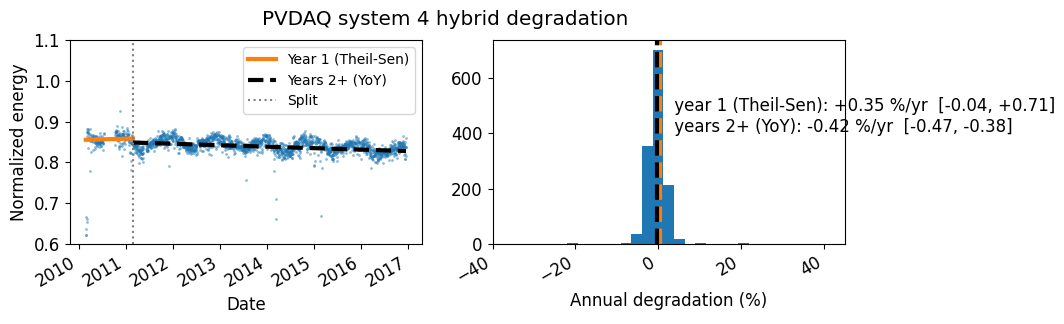

In [9]:
fig = ta.plot_hybrid_degradation_summary(
    'sensor',
    summary_title='PVDAQ system 4 hybrid degradation',
    scatter_ymin=0.6, scatter_ymax=1.1,
    hist_xmin=-40, hist_xmax=45,
)
plt.show()


## 5. Seasonal hybrid analysis: Fourier on year 1

Section 3 used a plain median slope on the raw year-1 window, treating
the seasonal wiggle as noise. That is unbiased on average, but when the
year-1 trend is small compared to the seasonal amplitude the reported
rate can shift depending on where in the annual cycle year 1 lands —
the trend and the arc of a single seasonal cycle are not well
separated. This section upgrades **only the year-1 piece** of the
hybrid to the Fourier estimator
([`degradation_fourier`](../api.html#rdtools.degradation_fourier));
the years-2+ piece is exactly the same year-on-year call as in §3.

- **Year 1: seasonal Fourier estimator.** Two stages that split the
  estimation labor between the multi-year record and the year-1
  slice:

    1. **Stage 1** — learn the seasonal shape from the multi-year
       record. Fit a linear trend plus `harmonics` pairs of sine/cosine
       regressors so the seasonal pattern is constrained by every cycle
       the data contains. Year 1 is **excluded by default**
       (`skip_year1_in_seasonal_fit=True`), on the grounds that the
       reason to reach for this estimator in the first place is
       typically that year 1 is suspect (LeTID, light-soaking, initial
       stabilization) and letting it into the seasonal fit risks
       absorbing that transient into the harmonic coefficients. Pass
       `skip_year1_in_seasonal_fit=False` if year 1 is trusted to look
       like steady state and you want the extra data.

       How the trend is estimated at stage 1 is selectable via
       `seasonal_trend_method`:

         - `'yoy'` (default) — first estimate the trend robustly with the
           year-on-year median-of-pairwise-annual-slopes
           ([`degradation_year_on_year`](../api.html#rdtools.degradation_year_on_year)),
           detrend, then OLS-fit only the intercept + Fourier regressors
           on the residual. YoY is immune to any stationary
           365-day-periodic seasonality (it differences it out) and
           resistant to a handful of outlier days.
         - `'ols'` — jointly fit intercept + trend + Fourier regressors
           in a single OLS call. Faster and works on shorter records,
           but sensitive to outliers in the multi-year record.

    2. **Stage 2** — fit the year-1 slope on the deseasonalized year-1
       slice. Subtract the fitted seasonal pattern from the first 365
       days of the series and fit a straight-line slope through what
       remains. The `slope_method` kwarg picks the stage-2 regression:

         - `'theil_sen'` (default) — robust median-of-pairwise-slopes fit
           ([`degradation_theil_sen`](../api.html#rdtools.degradation_theil_sen))
           with a rank-based CI, resistant to bad days in the year-1
           window.
         - `'ols'` — parametric uncertainty via Monte-Carlo on the OLS
           covariance; slightly narrower interval when residuals are
           Gaussian.

    Stage-1 Fourier-coefficient fitting always uses OLS (the
    multi-regressor sine/cosine design has no clean robust univariate
    analog, and stage 1 sees enough data across many cycles for
    individual outliers to wash out).

- **Years 2+: standard year-on-year (unchanged from §3).** The hybrid
  framework always calls
  [`degradation_year_on_year`](../api.html#rdtools.degradation_year_on_year)
  on the post-year-1 window; that call is decoupled from the year-1
  method, so the years-2+ rate reported here will match the one from
  §3 to the last digit.

The next two cells run the estimator with its built-in defaults and
plot the summary; §5.1 then departs from the defaults on each axis in
turn to show how each knob moves the reported year-1 rate.


In [10]:
# Run the hybrid analysis with the Fourier year-1 method at its built-in
# defaults: seasonal_trend_method='yoy' (robust YoY-median trend at stage 1)
# and slope_method='theil_sen' (robust median slope at stage 2).
ta.sensor_analysis(
    analyses=['hybrid_degradation'],
    hybrid_kwargs={'year1_method': 'fourier'},
)
fourier_default = ta.results['sensor']['hybrid_degradation']

ci1 = fourier_default['calc_info']['year1'][1]
ci2 = fourier_default['calc_info']['years2plus'][1]
print("Hybrid with Fourier year-1 method (defaults):")
print(f"  year 1   Rd = {fourier_default['rd_pct_year1']:+.3f} %/yr   "
      f"68% CI = [{ci1[0]:+.3f}, {ci1[1]:+.3f}]")
print(f"  years 2+ Rd = {fourier_default['rd_pct_years2plus']:+.3f} %/yr   "
      f"68% CI = [{ci2[0]:+.3f}, {ci2[1]:+.3f}]")


Hybrid with Fourier year-1 method (defaults):
  year 1   Rd = -1.344 %/yr   68% CI = [-1.664, -1.009]
  years 2+ Rd = -0.422 %/yr   68% CI = [-0.469, -0.377]


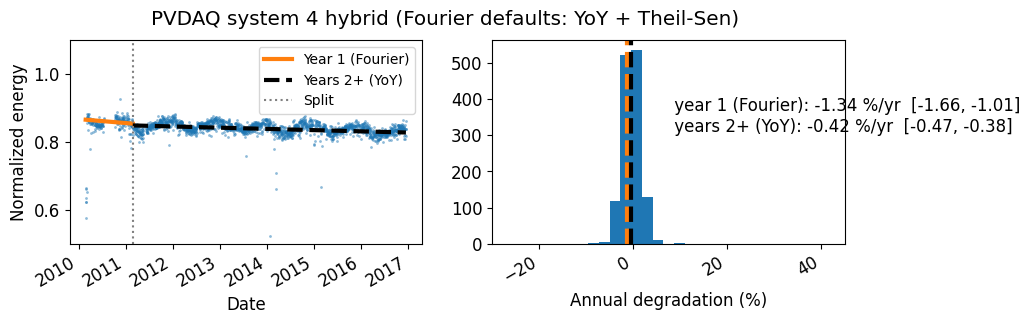

In [11]:
# Plot the two-panel summary for the Fourier default run above.
fig = ta.plot_hybrid_degradation_summary(
    'sensor',
    summary_title='PVDAQ system 4 hybrid (Fourier defaults: YoY + Theil-Sen)',
    scatter_ymin=0.5, scatter_ymax=1.1,
    hist_xmin=-30, hist_xmax=45,
)
plt.show()


### 5.1 Exploring the options

The Fourier estimator has two independent knobs, both defaulting to the
robust choice: `seasonal_trend_method='yoy'` (stage 1 trend estimate)
and `slope_method='theil_sen'` (stage 2 slope on the deseasonalized
year-1 window). Below we flip each one in turn, holding the other at
its default, so it's easy to attribute any change in the reported rate
to a single knob.

The `years 2+` column is identical across the three Fourier rows — it
comes from a fixed YoY call on the post-split window and is decoupled
from the year-1 method choice. A final row shows the standard
whole-series YoY rate (from §3) for reference: its distance from the
hybrid years-2+ number is a rough measure of how much year 1 shifts a
naive single-rate estimate that ignores the split.


In [12]:
# Alt 1: joint OLS at stage 1 (Theil-Sen stage 2 unchanged).
ta.sensor_analysis(
    analyses=['hybrid_degradation'],
    hybrid_kwargs={'year1_method': 'fourier',
                   'year1_kwargs': {'seasonal_trend_method': 'ols'}},
)
fourier_ols_trend = ta.results['sensor']['hybrid_degradation']

# Alt 2: OLS stage-2 slope (YoY stage 1 unchanged).
ta.sensor_analysis(
    analyses=['hybrid_degradation'],
    hybrid_kwargs={'year1_method': 'fourier',
                   'year1_kwargs': {'slope_method': 'ols'}},
)
fourier_ols_slope = ta.results['sensor']['hybrid_degradation']


def _row(label, result):
    ci1 = result['calc_info']['year1'][1]
    return (f"  {label:<44}  {result['rd_pct_year1']:+7.3f}  "
            f"[{ci1[0]:+6.3f}, {ci1[1]:+6.3f}]  |  "
            f"{result['rd_pct_years2plus']:+7.3f}")


print("Fourier year-1 method: departures from defaults on each axis")
print(f"  {'configuration':<44}  {'year-1':>7}  "
      f"{'year-1 68% CI':>16}     {'years 2+':>7}")
print("  " + "-" * 88)
print(_row("defaults (YoY trend, Theil-Sen slope)", fourier_default))
print(_row("seasonal_trend_method='ols' (OLS trend)", fourier_ols_trend))
print(_row("slope_method='ols' (OLS slope)", fourier_ols_slope))
print("  " + "-" * 88)
# Reference: standard whole-series YoY from section 3 (single rate, no
# year-1/year-2+ split). Its distance from the hybrid years-2+ number
# above is a rough measure of how much year 1 shifts a naive single-rate
# estimate that treats the whole record uniformly.
print(f"  {'standard YoY, whole series (no split)':<44}  "
      f"{'—':>7}  {'—':>16}     {yoy_results['p50_rd']:+7.3f}")


Fourier year-1 method: departures from defaults on each axis
  configuration                                  year-1     year-1 68% CI     years 2+
  ----------------------------------------------------------------------------------------
  defaults (YoY trend, Theil-Sen slope)          -1.344  [-1.664, -1.009]  |   -0.422
  seasonal_trend_method='ols' (OLS trend)        -1.374  [-1.695, -1.035]  |   -0.422
  slope_method='ols' (OLS slope)                 +2.255  [+1.230, +3.281]  |   -0.422
  ----------------------------------------------------------------------------------------
  standard YoY, whole series (no split)               —                 —      -0.456
